States loaded: 35
['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli & Daman and Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharastra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand']

Missing values:
 State               0
Obesity_Women       0
Obesity_Men         0
Anaemia_Children    0
Anaemia_Women       0
BloodSugar_Women    0
BloodSugar_Men      0
Hyper_Women         0
Hyper_Men           0
dtype: int64

Sample:
                        State  Obesity_Women  Obesity_Men  Anaemia_Children  Anaemia_Women  BloodSugar_Women  BloodSugar_Men  Hyper_Women  Hyper_Men
0  Andaman & Nicobar Islands           38.1         45.3              40.0           

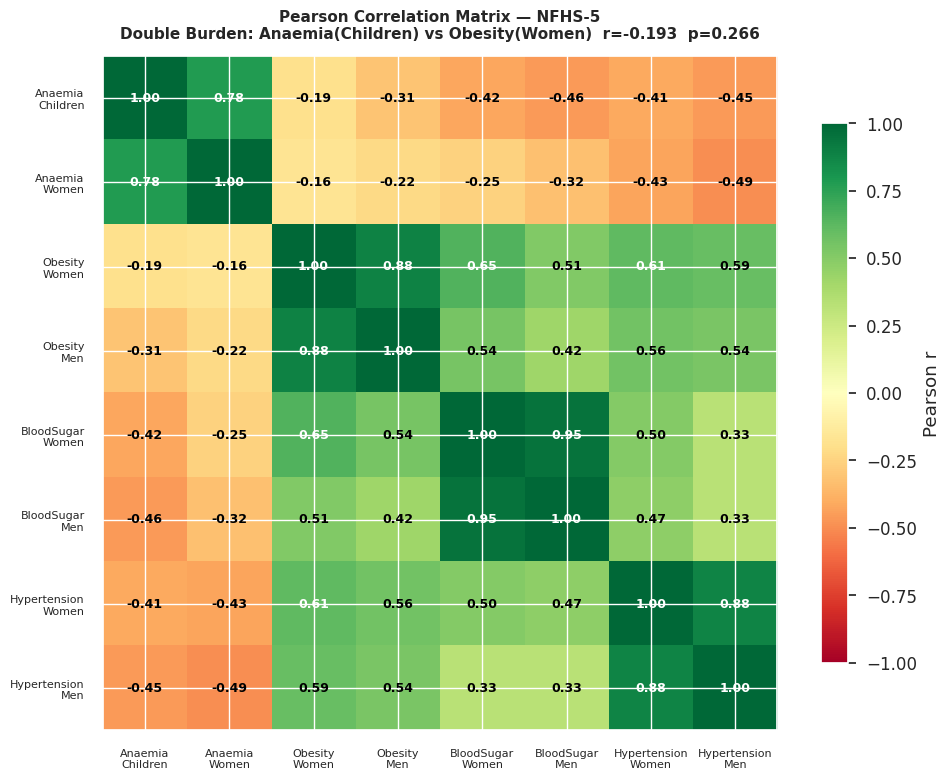

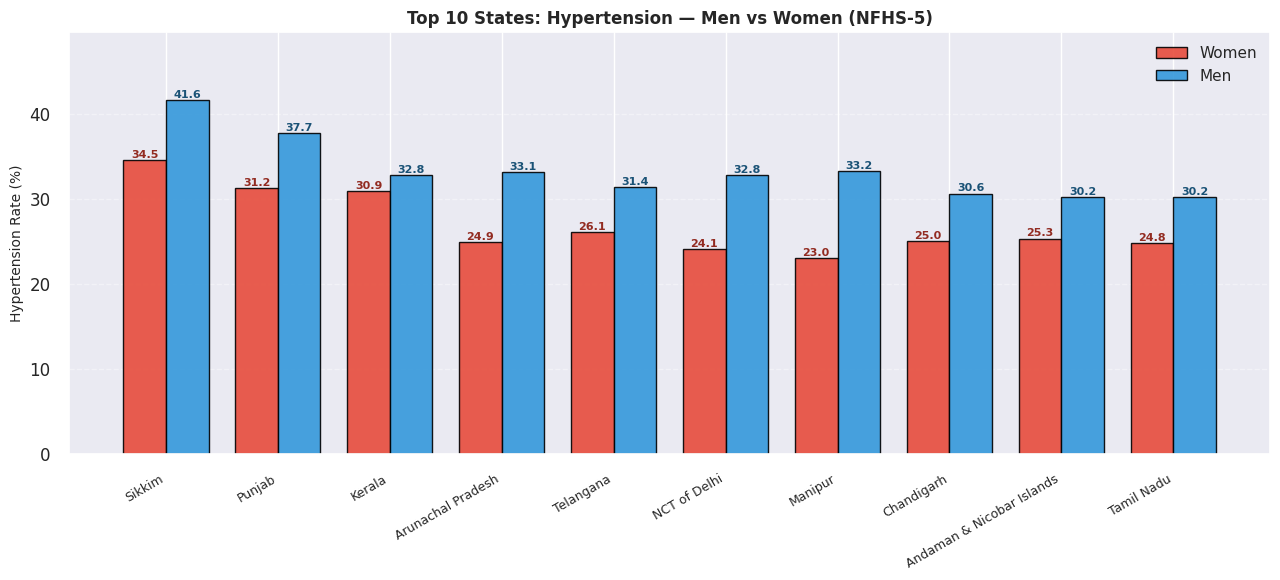

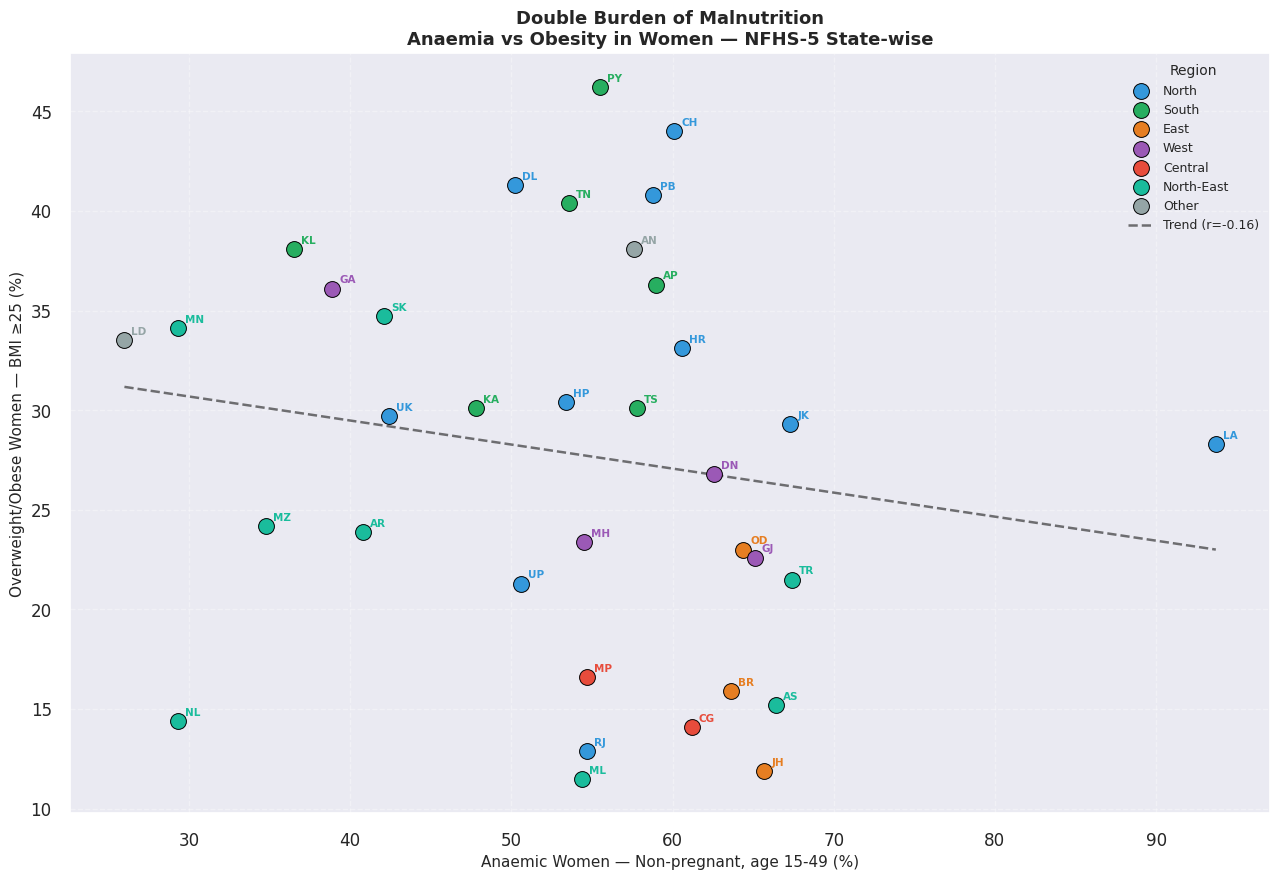

Phase 2 complete — 3 plots saved.
GeoJSON downloaded
Folium map saved: nfhs5_india_map.html


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import folium
import json
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# ============================================================
#  PHASE 1 : Data Setup and Aggregation
# ============================================================

df_raw = pd.read_csv('/content/datafile.csv')

df = df_raw[(df_raw['Area'] == 'Total') &
            (df_raw['States/UTs'] != 'India')].copy().reset_index(drop=True)

print(f"States loaded: {len(df)}")
print(df['States/UTs'].tolist())

# ── Step 2: Select key health columns ───────────────────────
COL = {
    'State'           : 'States/UTs',
    'Obesity_Women'   : 'Women (age 15-49 years) who are overweight or obese (BMI \u226525.0 kg/m2)21 (%)',
    'Obesity_Men'     : 'Men (age 15-49 years) who are overweight or obese (BMI \u226525.0 kg/m2) (%)',
    'Anaemia_Children': 'Children age 6-59 months who are anaemic (<11.0 g/dl)22 (%)',
    'Anaemia_Women'   : 'Non-pregnant women age 15-49 years who are anaemic (<12.0 g/dl)22 (%)',
    'BloodSugar_Women': 'Women age 15 years and above wih high or very high (>140 mg/dl) Blood sugar level or taking medicine to control blood sugar level23 (%)',
    'BloodSugar_Men'  : 'Men age 15 years and above wih high or very high (>140 mg/dl) Blood sugar level  or taking medicine to control blood sugar level23 (%)',
    'Hyper_Women'     : 'Women age 15 years and above wih Elevated blood pressure (Systolic \u2265140 mm of Hg and/or Diastolic \u226590 mm of Hg) or taking medicine to control blood pressure (%)',
    'Hyper_Men'       : 'Men age 15 years and above wih Elevated blood pressure (Systolic \u2265140 mm of Hg and/or Diastolic \u226590 mm of Hg) or taking medicine to control blood pressure (%)',
}

df_health = df[[COL[k] for k in COL]].copy()
df_health.columns = list(COL.keys())

# ── Step 3: Clean — coerce non-numeric / hyphens to NaN ────
for col in df_health.columns:
    if col == 'State':
        continue
    df_health[col] = (df_health[col]
                      .astype(str).str.strip()
                      .replace(['-','--','na','NA','N/A',''], np.nan))
    df_health[col] = pd.to_numeric(df_health[col], errors='coerce')

print("\nMissing values:\n", df_health.isnull().sum())
print("\nSample:\n", df_health.head(3).to_string())

# ── Step 4: Gender_Obesity_Gap ──────────────────────────────
df_health['Gender_Obesity_Gap'] = df_health['Obesity_Women'] - df_health['Obesity_Men']

print("\nTop 5 Gender Obesity Gap:")
print(df_health[['State','Obesity_Women','Obesity_Men','Gender_Obesity_Gap']]
      .sort_values('Gender_Obesity_Gap', ascending=False).head())

# ── Maps: abbreviation & region ─────────────────────────────
ABBR = {
    'Andaman & Nicobar Islands':'AN', 'Andhra Pradesh':'AP',
    'Arunachal Pradesh':'AR', 'Assam':'AS', 'Bihar':'BR',
    'Chandigarh':'CH', 'Chhattisgarh':'CG',
    'Dadra and Nagar Haveli & Daman and Diu':'DN',
    'Goa':'GA', 'Gujarat':'GJ', 'Haryana':'HR',
    'Himachal Pradesh':'HP', 'Jammu & Kashmir':'JK',
    'Jharkhand':'JH', 'Karnataka':'KA', 'Kerala':'KL',
    'Ladakh':'LA', 'Lakshadweep':'LD', 'Madhya Pradesh':'MP',
    'Maharastra':'MH', 'Manipur':'MN', 'Meghalaya':'ML',
    'Mizoram':'MZ', 'Nagaland':'NL', 'NCT of Delhi':'DL',
    'Odisha':'OD', 'Puducherry':'PY', 'Punjab':'PB',
    'Rajasthan':'RJ', 'Sikkim':'SK', 'Tamil Nadu':'TN',
    'Telangana':'TS', 'Tripura':'TR', 'Uttar Pradesh':'UP',
    'Uttarakhand':'UK', 'West Bengal':'WB',
}
REGION = {
    'Andaman & Nicobar Islands':'Other',
    'Andhra Pradesh':'South', 'Arunachal Pradesh':'North-East',
    'Assam':'North-East', 'Bihar':'East', 'Chandigarh':'North',
    'Chhattisgarh':'Central',
    'Dadra and Nagar Haveli & Daman and Diu':'West',
    'Goa':'West', 'Gujarat':'West', 'Haryana':'North',
    'Himachal Pradesh':'North', 'Jammu & Kashmir':'North',
    'Jharkhand':'East', 'Karnataka':'South', 'Kerala':'South',
    'Ladakh':'North', 'Lakshadweep':'Other',
    'Madhya Pradesh':'Central', 'Maharastra':'West',
    'Manipur':'North-East', 'Meghalaya':'North-East',
    'Mizoram':'North-East', 'Nagaland':'North-East',
    'NCT of Delhi':'North', 'Odisha':'East',
    'Puducherry':'South', 'Punjab':'North', 'Rajasthan':'North',
    'Sikkim':'North-East', 'Tamil Nadu':'South',
    'Telangana':'South', 'Tripura':'North-East',
    'Uttar Pradesh':'North', 'Uttarakhand':'North',
    'West Bengal':'East',
}
df_health['Abbr']   = df_health['State'].map(ABBR).fillna('??')
df_health['Region'] = df_health['State'].map(REGION).fillna('Other')

# ============================================================
#  PHASE 2 : EDA and Plotting
# ============================================================

# ── Task 1: Correlation Matrix ───────────────────────────────
corr_cols = ['Anaemia_Children','Anaemia_Women',
             'Obesity_Women','Obesity_Men',
             'BloodSugar_Women','BloodSugar_Men',
             'Hyper_Women','Hyper_Men']
corr_matrix = df_health[corr_cols].corr(method='pearson')

valid = df_health[['Anaemia_Children','Obesity_Women']].dropna()
r, p = stats.pearsonr(valid['Anaemia_Children'], valid['Obesity_Women'])
print(f"\n[Task 1] Double Burden — Pearson r = {r:.3f},  p = {p:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
labels = ['Anaemia\nChildren','Anaemia\nWomen',
          'Obesity\nWomen','Obesity\nMen',
          'BloodSugar\nWomen','BloodSugar\nMen',
          'Hypertension\nWomen','Hypertension\nMen']
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        v = corr_matrix.values[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if abs(v) > 0.6 else 'black')
ax.set_title(
    f'Pearson Correlation Matrix — NFHS-5\n'
    f'Double Burden: Anaemia(Children) vs Obesity(Women)  r={r:.3f}  p={p:.3f}',
    fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('task1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Task 2: Grouped Bar — Top 10 Hypertension States ────────
df_hyper = df_health[['State','Hyper_Women','Hyper_Men']].dropna()
df_hyper['Avg'] = (df_hyper['Hyper_Women'] + df_hyper['Hyper_Men']) / 2
top10 = df_hyper.nlargest(10,'Avg').reset_index(drop=True)

x, w = np.arange(len(top10)), 0.38
fig, ax = plt.subplots(figsize=(13,6))
bw = ax.bar(x-w/2, top10['Hyper_Women'], w, label='Women',
            color='#e74c3c', edgecolor='black', alpha=0.9)
bm = ax.bar(x+w/2, top10['Hyper_Men'],   w, label='Men',
            color='#3498db', edgecolor='black', alpha=0.9)
for b in bw:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{b.get_height():.1f}', ha='center', fontsize=8,
            color='#922b21', fontweight='bold')
for b in bm:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{b.get_height():.1f}', ha='center', fontsize=8,
            color='#1a5276', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top10['State'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Hypertension Rate (%)', fontsize=10)
ax.set_title('Top 10 States: Hypertension — Men vs Women (NFHS-5)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
ax.set_ylim(0, top10[['Hyper_Women','Hyper_Men']].max().max()+8)
plt.tight_layout()
plt.savefig('task2_hypertension_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Task 3: Scatter — Anaemic Women vs Obese Women ──────────
RCOL = {'North':'#3498db','South':'#27ae60','East':'#e67e22',
        'West':'#9b59b6','Central':'#e74c3c',
        'North-East':'#1abc9c','Other':'#95a5a6'}

ds = df_health[['State','Abbr','Region','Anaemia_Women','Obesity_Women']].dropna()

fig, ax = plt.subplots(figsize=(13,9))
for region, color in RCOL.items():
    sub = ds[ds['Region']==region]
    if sub.empty: continue
    ax.scatter(sub['Anaemia_Women'], sub['Obesity_Women'],
               color=color, s=130, edgecolors='black',
               linewidth=0.7, label=region, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['Abbr'],
                    xy=(row['Anaemia_Women'], row['Obesity_Women']),
                    xytext=(5,4), textcoords='offset points',
                    fontsize=7.5, fontweight='bold', color=color)

m2, b2, r2, p2, _ = stats.linregress(ds['Anaemia_Women'], ds['Obesity_Women'])
xl = np.linspace(ds['Anaemia_Women'].min(), ds['Anaemia_Women'].max(), 200)
ax.plot(xl, m2*xl+b2, 'k--', lw=1.8, alpha=0.6,
        label=f'Trend (r={r2:.2f})')

ax.set_xlabel('Anaemic Women — Non-pregnant, age 15-49 (%)', fontsize=11)
ax.set_ylabel('Overweight/Obese Women — BMI \u226525 (%)', fontsize=11)
ax.set_title('Double Burden of Malnutrition\nAnaemia vs Obesity in Women — NFHS-5 State-wise',
             fontsize=13, fontweight='bold')
ax.legend(title='Region', fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('task3_scatter_anaemia_obesity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Phase 2 complete — 3 plots saved.")

# ============================================================
#  PHASE 3 : Folium Geographic Visualization
# ============================================================

CAPITALS = {
    'Andhra Pradesh':   ('Amaravati',     16.5062, 80.6480),
    'Arunachal Pradesh':('Itanagar',      27.0844, 93.6053),
    'Assam':            ('Dispur',        26.1433, 91.7898),
    'Bihar':            ('Patna',         25.5941, 85.1376),
    'Chhattisgarh':     ('Raipur',        21.2514, 81.6296),
    'Goa':              ('Panaji',        15.4909, 73.8278),
    'Gujarat':          ('Gandhinagar',   23.2156, 72.6369),
    'Haryana':          ('Chandigarh',    30.7333, 76.7794),
    'Himachal Pradesh': ('Shimla',        31.1048, 77.1734),
    'Jammu & Kashmir':  ('Srinagar',      34.0837, 74.7973),
    'Jharkhand':        ('Ranchi',        23.3441, 85.3096),
    'Karnataka':        ('Bengaluru',     12.9716, 77.5946),
    'Kerala':           ('Thiruvananthapuram', 8.5241, 76.9366),
    'Madhya Pradesh':   ('Bhopal',        23.2599, 77.4126),
    'Maharastra':       ('Mumbai',        19.0760, 72.8777),
    'Manipur':          ('Imphal',        24.8170, 93.9368),
    'Meghalaya':        ('Shillong',      25.5788, 91.8933),
    'Mizoram':          ('Aizawl',        23.7271, 92.7176),
    'Nagaland':         ('Kohima',        25.6701, 94.1077),
    'Odisha':           ('Bhubaneswar',   20.2961, 85.8245),
    'Punjab':           ('Chandigarh',    30.7333, 76.7794),
    'Rajasthan':        ('Jaipur',        26.9124, 75.7873),
    'Sikkim':           ('Gangtok',       27.3389, 88.6065),
    'Tamil Nadu':       ('Chennai',       13.0827, 80.2707),
    'Telangana':        ('Hyderabad',     17.3850, 78.4867),
    'Tripura':          ('Agartala',      23.8315, 91.2868),
    'Uttar Pradesh':    ('Lucknow',       26.8467, 80.9462),
    'Uttarakhand':      ('Dehradun',      30.3165, 78.0322),
    'West Bengal':      ('Kolkata',       22.5726, 88.3639),
    'NCT of Delhi':     ('New Delhi',     28.6139, 77.2090),
    'Ladakh':           ('Leh',           34.1526, 77.5771),
    'Chandigarh':       ('Chandigarh',    30.7333, 76.7794),
    'Puducherry':       ('Puducherry',    11.9416, 79.8083),
    'Andaman & Nicobar Islands': ('Port Blair', 11.6234, 92.7265),
    'Lakshadweep':      ('Kavaratti',     10.5669, 72.6420),
    'Dadra and Nagar Haveli & Daman and Diu': ('Daman', 20.3974, 72.8328),
}

# ── Step 2: Download GeoJSON + build Choropleth ─────────────
GEOJSON_URL = (
    "https://raw.githubusercontent.com/geohacker/india/"
    "master/state/india_telengana.geojson"
)
geojson_path = 'india_states.geojson'
urllib.request.urlretrieve(GEOJSON_URL, geojson_path)
print("GeoJSON downloaded")

# Fix state name mismatches between datafile and GeoJSON
NAME_MAP = {
    'Maharastra'                             : 'Maharashtra',
    'Jammu & Kashmir'                        : 'Jammu and Kashmir',
    'Andaman & Nicobar Islands'              : 'Andaman and Nicobar',
    'Dadra and Nagar Haveli & Daman and Diu' : 'Dadra and Nagar Haveli',
    'NCT of Delhi'                           : 'Delhi',
}
df_health['GeoName'] = df_health['State'].replace(NAME_MAP)

# ── Step 1: Initialize Folium map ───────────────────────────
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5,
               tiles='CartoDB positron')

# ── Choropleth layer — Obesity (Women) ──────────────────────
obesity_series = df_health.set_index('GeoName')['Obesity_Women'].dropna()

folium.Choropleth(
    geo_data=geojson_path,
    name='Obesity Women (%)',
    data=obesity_series,
    key_on='feature.properties.NAME_1',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Women Overweight/Obese — BMI \u226525 (%)',
    nan_fill_color='#eeeeee',
    nan_fill_opacity=0.4,
).add_to(m)

# ── Step 3: CircleMarker per state capital ───────────────────
for _, row in df_health.iterrows():
    state = row['State']
    if state not in CAPITALS:
        continue
    cap, lat, lon = CAPITALS[state]

    bs  = row['BloodSugar_Women']
    an  = row['Anaemia_Women']
    ob  = row['Obesity_Women']
    hyp = row['Hyper_Women']
    gap = row['Gender_Obesity_Gap']

    # Colour circle by obesity level
    dot_color = ('#c0392b' if ob > 35 else
                 '#e67e22' if ob > 25 else
                 '#f1c40f' if ob > 15 else '#27ae60')

    card = f"""
    <div style="font-family:Arial;font-size:13px;width:230px;">
      <b style="font-size:14px;color:#c0392b;">{state}</b><br>
      <i style="color:#777;">Capital: {cap}</i>
      <hr style="margin:5px 0;">
      🩸 <b>High Blood Sugar (Women):</b> {bs:.1f}%<br>
      💉 <b>Anaemia (Women):</b> {an:.1f}%<br>
      ⚖️ <b>Obesity (Women):</b> {ob:.1f}%<br>
      ❤️ <b>Hypertension (Women):</b> {hyp:.1f}%<br>
      <hr style="margin:5px 0;">
      <b>Gender Obesity Gap:</b> {gap:+.1f}%
    </div>
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        color='black', weight=1,
        fill=True, fill_color=dot_color, fill_opacity=0.85,
        tooltip=folium.Tooltip(card, sticky=True),
        popup=folium.Popup(card, max_width=250),
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save('nfhs5_india_map.html')
print("Folium map saved: nfhs5_india_map.html")

# Display inside Colab
from IPython.display import IFrame
IFrame('nfhs5_india_map.html', width='100%', height=600)